# Notebook to Analyse Results from Model Training and Evaluation


author: Kananelo Chabeli

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from math import pi
import warnings
warnings.filterwarnings('ignore')


In [2]:
#define global Constants

MODEL_COLORS = {
    'RandomForest': '#4fc3f7',
    'CatBoost':     '#81c784',
    'ExtraTrees':   '#ffb74d',
    'AdaBoost':     '#f06292',
    'LightGBM':     '#ce93d8',
    'XGBoost':      '#ff8a65',
}
MODELS    = list(MODEL_COLORS.keys())
PALETTE   = list(MODEL_COLORS.values())
DS_COLORS = {'CustomDataset': '#4fc3f7', 'CICIoT-DIAD2024': '#ff8a65'}

## Build DataFrame from the Raw data. This data was extracted from notebooks that used CICIoT-diad2024 AND Custom Datasets

In [3]:
columns = ['Model','Dataset','CPU_Train','CPU_Inf',
           'Train_Time','Inf_Time','Accuracy','Precision','Recall','F1']

raw = [
    # CustomDataset  (14 978 samples, 70/30 split)
    ('RandomForest','CustomDataset', 34.55,26.70, 0.2871,0.0433, 99.61,99.61,99.61,99.61),
    ('CatBoost',    'CustomDataset', 62.44,18.20, 1.2600,0.0050, 99.61,99.61,99.61,99.61),
    ('ExtraTrees',  'CustomDataset', 17.65, 3.10, 0.2172,0.0528, 99.45,99.45,99.45,99.45),
    ('AdaBoost',    'CustomDataset', 12.84, 3.70, 1.8600,0.0240, 99.41,99.41,99.41,99.41),
    ('LightGBM',    'CustomDataset', 51.00,28.00, 6.1820,0.0816, 99.77,99.76,99.77,99.76),
    ('XGBoost',     'CustomDataset', 94.34,73.50, 3.6000,0.0200, 99.69,99.69,99.69,99.69),
    # CICIoT-DIAD2024  (470 464 samples)
    ('RandomForest','CICIoT-DIAD2024', 94.39,14.90,  9.4869,0.1550, 96.01,96.37,96.01,96.16),
    ('CatBoost',    'CICIoT-DIAD2024', 91.27, 2.50, 37.5800,0.0078, 95.52,95.18,95.52,95.11),
    ('ExtraTrees',  'CICIoT-DIAD2024', 95.25,59.75, 11.5106,0.2930, 94.95,96.30,94.95,95.47),
    ('AdaBoost',    'CICIoT-DIAD2024', 17.35,17.06,458.7300,1.2080, 94.08,93.34,94.08,93.21),
    ('LightGBM',    'CICIoT-DIAD2024', 63.98,88.23, 71.4475,3.4515, 95.95,96.64,95.29,95.79),
    ('XGBoost',     'CICIoT-DIAD2024', 98.12,83.46, 62.9847,0.9786, 96.35,96.15,96.35,96.13),
]

df = pd.DataFrame(raw, columns=columns)


In [4]:
cds  = df[df['Dataset'] == 'CustomDataset'].set_index('Model')
cic  = df[df['Dataset'] == 'CICIoT-DIAD2024'].set_index('Model')

## Predictive Performance Results: Accuracy, Precision, Recall, F1-Score

### CICIoT-DIAD2024 Dataset Results

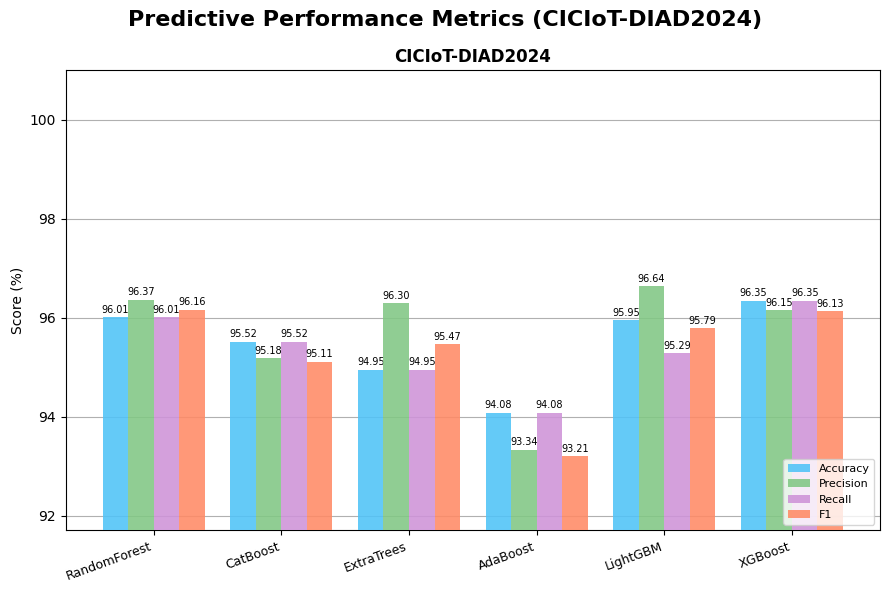

In [7]:
metrics = ['Accuracy','Precision','Recall','F1']
x       = np.arange(len(MODELS))
w       = 0.20
metric_colors = ['#4fc3f7','#81c784','#ce93d8','#ff8a65']

fig, ax = plt.subplots(figsize=(9, 6))
fig.suptitle('Predictive Performance Metrics (CICIoT-DIAD2024)', 
             fontsize=16, fontweight='bold')

# Only CIC dataset
for i, (m, col) in enumerate(zip(metrics, metric_colors)):
    vals = [cic.loc[mod, m] for mod in MODELS]
    bars = ax.bar(x + (i - 1.5) * w, vals, w, 
                  label=m, color=col, alpha=0.88, zorder=3)
    
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, 
                bar.get_height() + 0.05,
                f'{v:.2f}', 
                ha='center', va='bottom', 
                fontsize=7, color='#000000')

# Axis formatting
ymin = cic[metrics].values.min() - 1.5
ax.set_ylim(ymin, 101)
ax.set_xticks(x)
ax.set_xticklabels(MODELS, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Score (%)')
ax.set_title('CICIoT-DIAD2024', fontweight='bold')

ax.legend(loc='lower right', fontsize=8)
ax.yaxis.grid(True, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('fig_cic_performance_metrics.png', dpi=150, 
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

## Custom Dataset Results

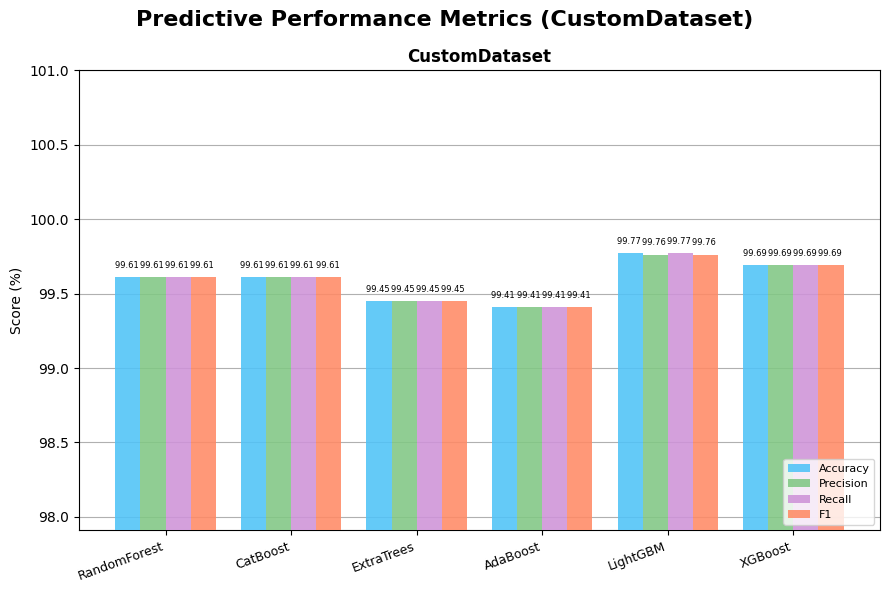

In [12]:
# metrics = ['Accuracy','Precision','Recall','F1']
# x       = np.arange(len(MODELS))
# w       = 0.20
# metric_colors = ['#4fc3f7','#81c784','#ce93d8','#ff8a65']

fig, ax = plt.subplots(figsize=(9, 6))
fig.suptitle('Predictive Performance Metrics (CustomDataset)', 
             fontsize=16, fontweight='bold')

# Only CustomDataset (cds)
for i, (m, col) in enumerate(zip(metrics, metric_colors)):
    vals = [cds.loc[mod, m] for mod in MODELS]
    bars = ax.bar(x + (i - 1.5) * w, vals, w, 
                  label=m, color=col, alpha=0.88, zorder=3)
    
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, 
                bar.get_height() + 0.05,
                f'{v:.2f} ', 
                ha='center', va='bottom', 
                fontsize=6, color='#000000')

# Axis formatting
ymin = cds[metrics].values.min() - 1.5
ax.set_ylim(ymin, 101)
ax.set_xticks(x)
ax.set_xticklabels(MODELS, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Score (%)')
ax.set_title('CustomDataset', fontweight='bold')

ax.legend(loc='lower right', fontsize=8)
ax.yaxis.grid(True, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('fig_cds_performance_metrics.png', dpi=150, 
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

# Resource Utilization: CPU Utilization(%) and Train + Infer Time

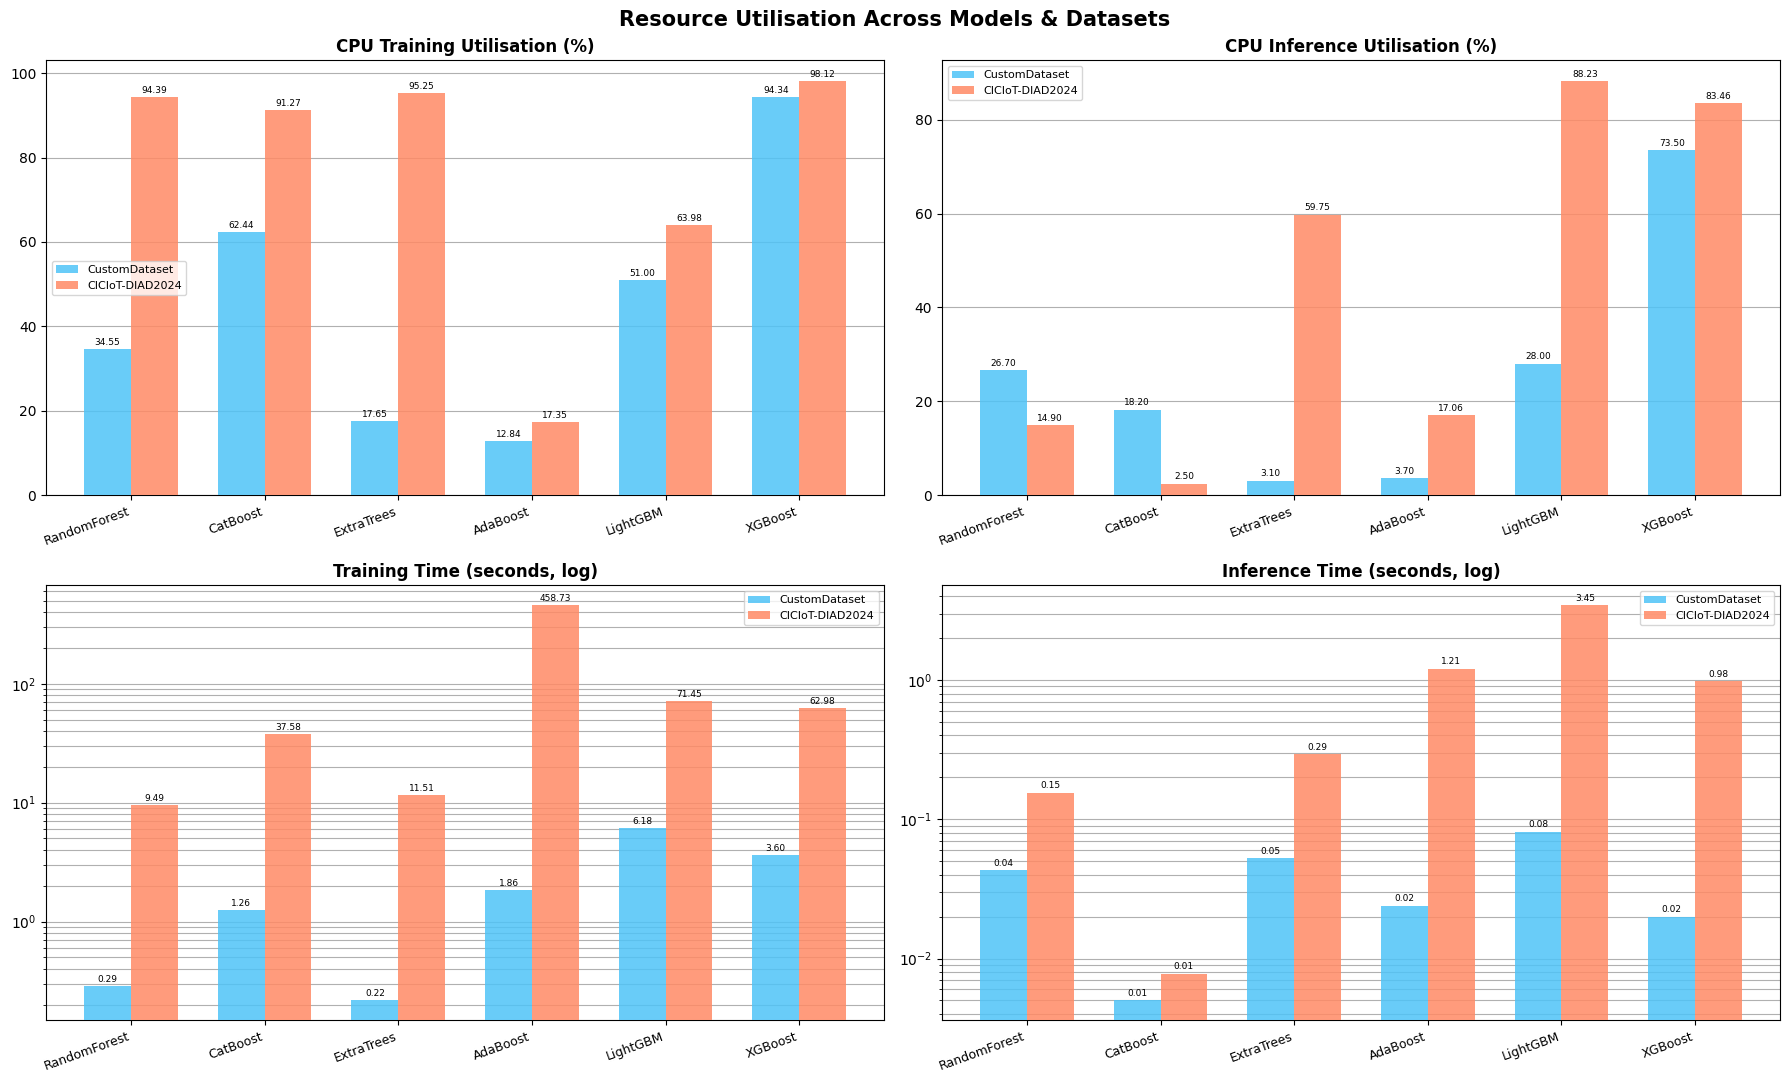

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle('Resource Utilisation Across Models & Datasets', fontsize=15, fontweight='bold')

configs = [
    ('CPU_Train',  'CPU Training Utilisation (%)',      axes[0,0]),
    ('CPU_Inf',    'CPU Inference Utilisation (%)',     axes[0,1]),
    ('Train_Time', 'Training Time (seconds, log)',      axes[1,0]),
    ('Inf_Time',   'Inference Time (seconds, log)',     axes[1,1]),
]

for col, title, ax in configs:
    use_log = 'log' in title
    w = 0.35
    x = np.arange(len(MODELS))

    v_cds = [cds.loc[m, col] for m in MODELS]
    v_cic = [cic.loc[m, col] for m in MODELS]

    b1 = ax.bar(x - w/2, v_cds, w, label='CustomDataset',   color='#4fc3f7', alpha=0.85, zorder=3)
    b2 = ax.bar(x + w/2, v_cic, w, label='CICIoT-DIAD2024', color='#ff8a65', alpha=0.85, zorder=3)

    if use_log:
        ax.set_yscale('log')

    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, rotation=20, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.yaxis.grid(True, zorder=0, which='both')
    ax.set_axisbelow(True)

    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2,
                    h * 1.04 if use_log else h + 0.5,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=6.5, color='#000000')

plt.tight_layout()
plt.savefig('fig2_resource_utilisation.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

# Performance VS Cost

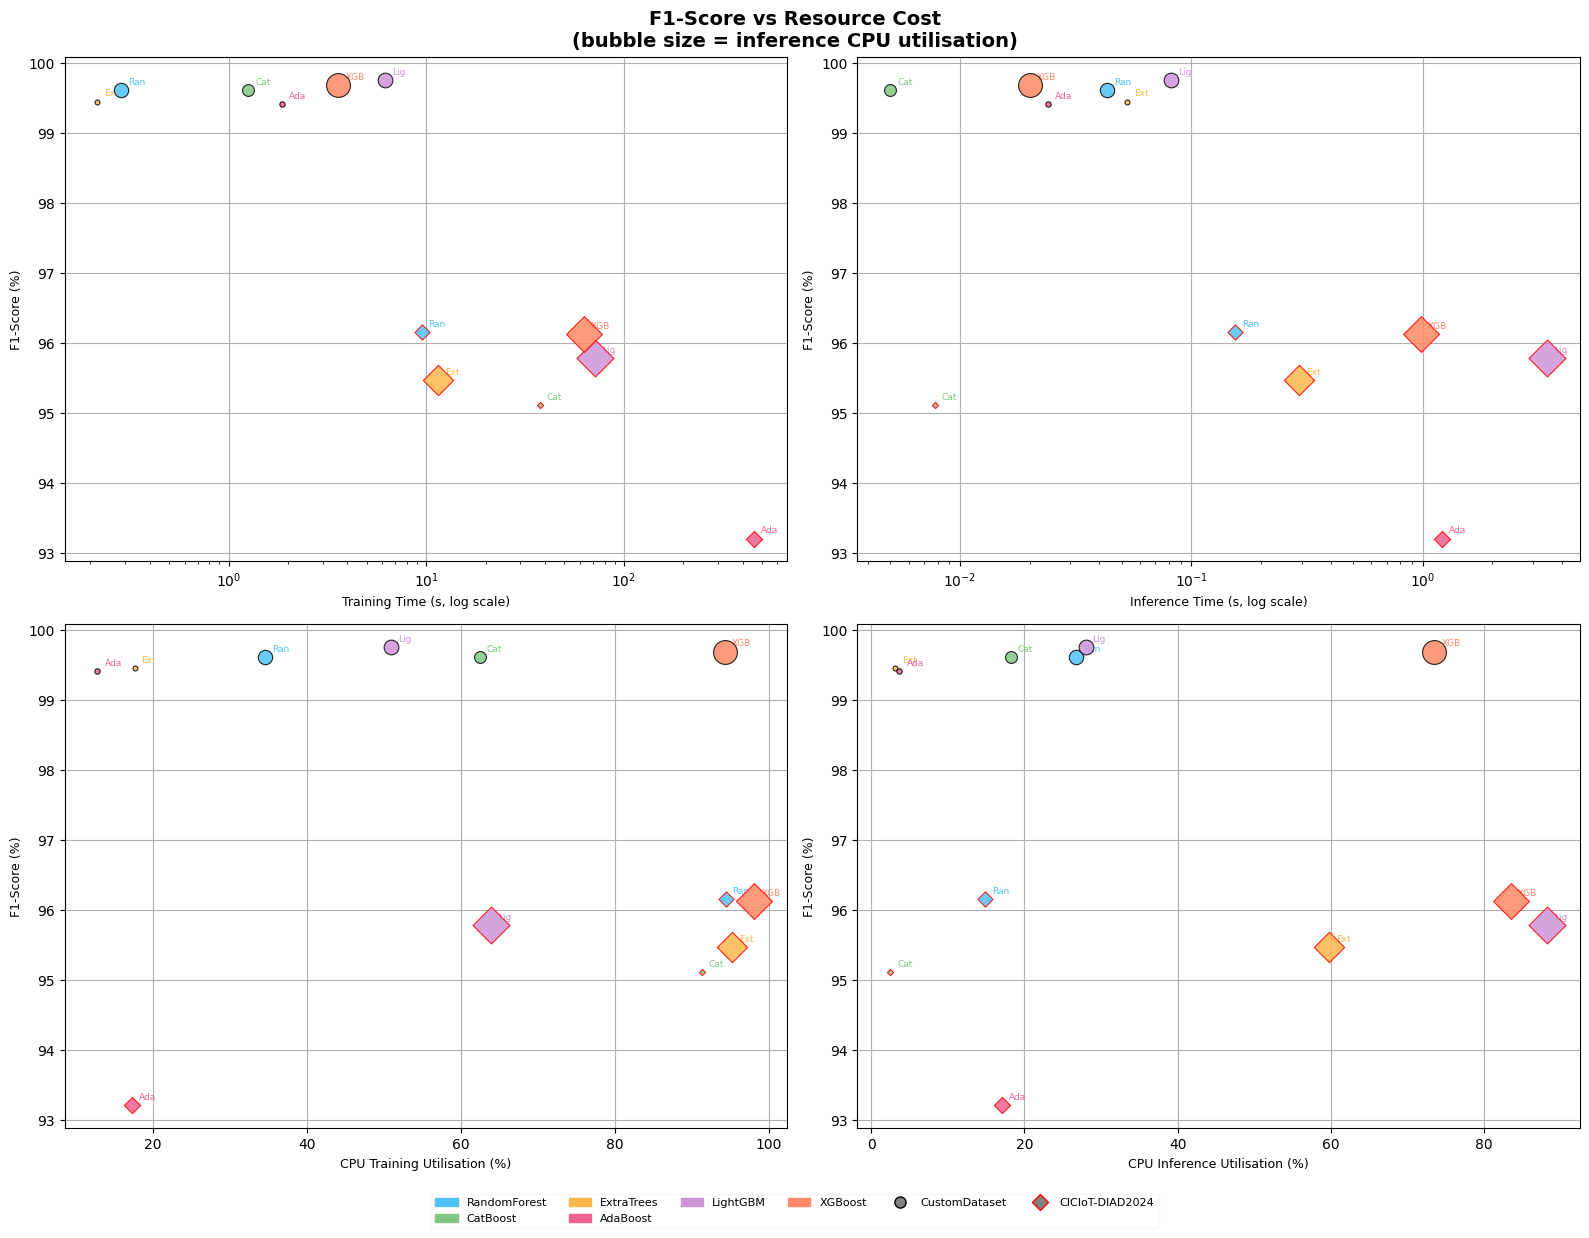

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('F1-Score vs Resource Cost\n(bubble size = inference CPU utilisation)',
             fontsize=14, fontweight='bold')

scatter_configs = [
    ('Train_Time', 'Training Time (s, log scale)', True,  axes[0,0]),
    ('Inf_Time',   'Inference Time (s, log scale)', True, axes[0,1]),
    ('CPU_Train',  'CPU Training Utilisation (%)', False, axes[1,0]),
    ('CPU_Inf',    'CPU Inference Utilisation (%)', False, axes[1,1]),
]

# Explicit dataset styling
DATASET_STYLE = {
    'CustomDataset':   {'marker': 'o', 'edgecolor': 'black'},
    'CICIoT-DIAD2024': {'marker': 'D', 'edgecolor': 'red'}
}

for xcol, xlabel, use_log, ax in scatter_configs:
    for ds_label, sub in [
            ('CustomDataset', cds),
            ('CICIoT-DIAD2024', cic)]:

        style = DATASET_STYLE[ds_label]

        for model in MODELS:
            x_val = sub.loc[model, xcol]
            y_val = sub.loc[model, 'F1']
            size  = sub.loc[model, 'CPU_Inf'] * 4

            ax.scatter(
                x_val, y_val,
                s=size,
                color=MODEL_COLORS[model],     # model identity
                marker=style['marker'],        # dataset identity
                edgecolors=style['edgecolor'], # dataset identity (strong cue)
                linewidths=0.8,
                alpha=0.85,
                zorder=4
            )

            ax.annotate(f'{model[:3]}',
                        (x_val, y_val),
                        textcoords='offset points',
                        xytext=(5, 4),
                        fontsize=6.5,
                        color=MODEL_COLORS[model])

    if use_log:
        ax.set_xscale('log')

    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('F1-Score (%)', fontsize=9)
    ax.yaxis.grid(True, zorder=0)
    ax.xaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)

# -----------------------------
# FIXED LEGEND (clear + correct)
# -----------------------------
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

# Model legend (colors)
model_handles = [
    mpatches.Patch(color=v, label=k) for k, v in MODEL_COLORS.items()
]

# Dataset legend (markers + edgecolors)
dataset_handles = [
    mlines.Line2D([], [], color='white',
                  marker='o', markerfacecolor='grey',
                  markeredgecolor='black', markersize=8,
                  linestyle='None', label='CustomDataset'),

    mlines.Line2D([], [], color='white',
                  marker='D', markerfacecolor='grey',
                  markeredgecolor='red', markersize=8,
                  linestyle='None', label='CICIoT-DIAD2024')
]

fig.legend(handles=model_handles + dataset_handles,
           loc='lower center', ncol=6, fontsize=8,
           bbox_to_anchor=(0.5, -0.04), framealpha=0.15)

plt.tight_layout()
plt.savefig('fig4_scatter_efficiency_fixed.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

# Cross Dataset Performance Drop

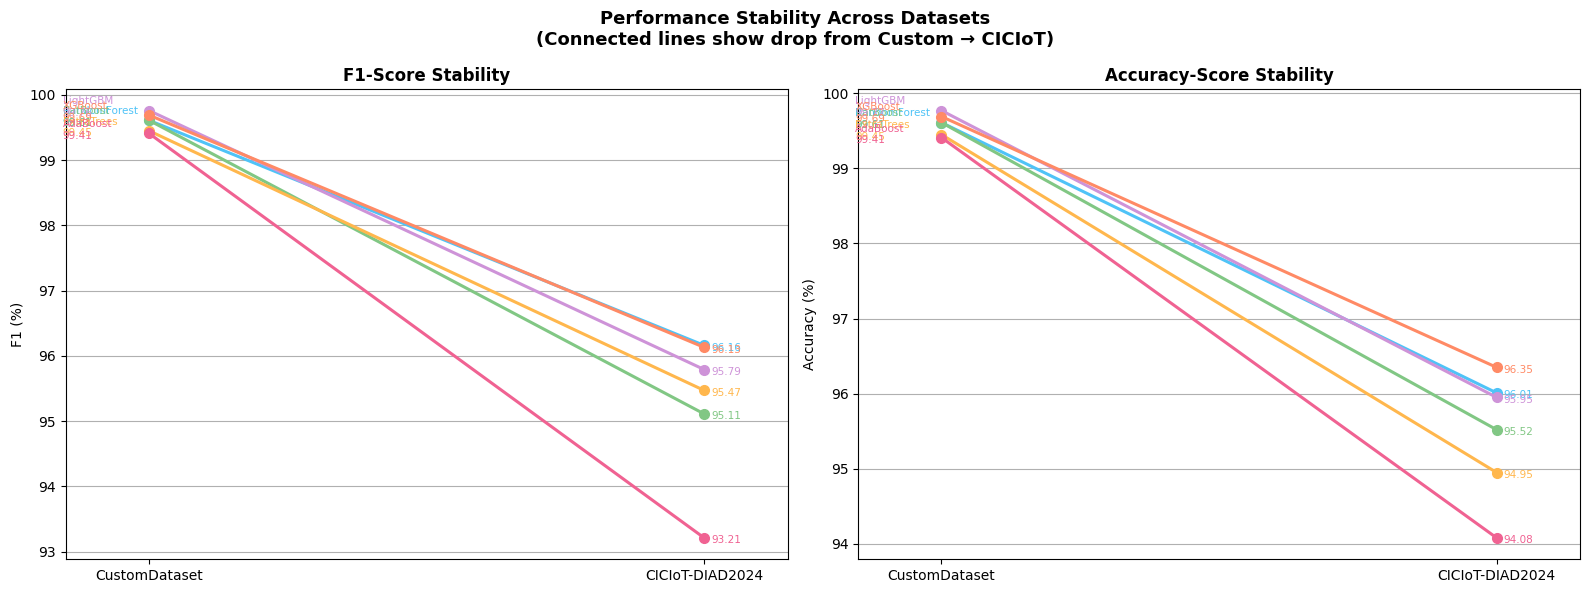

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Performance Stability Across Datasets\n(Connected lines show drop from Custom → CICIoT)',
             fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ['F1', 'Accuracy']):
    for model in MODELS:
        v_cds = cds.loc[model, metric]
        v_cic = cic.loc[model, metric]
        col   = MODEL_COLORS[model]
        ax.plot([0, 1], [v_cds, v_cic], '-o', color=col, linewidth=2.2,
                markersize=7, label=model, zorder=4)
        ax.annotate(f'{model}\n{v_cds:.2f}', (0, v_cds),
                    textcoords='offset points', xytext=(-62, -4),
                    fontsize=7.5, color=col)
        ax.annotate(f'{v_cic:.2f}', (1, v_cic),
                    textcoords='offset points', xytext=(5, -4),
                    fontsize=7.5, color=col)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['CustomDataset', 'CICIoT-DIAD2024'], fontsize=10)
    ax.set_ylabel(f'{metric} (%)', fontsize=10)
    ax.set_title(f'{metric}-Score Stability', fontweight='bold')
    ax.set_xlim(-0.15, 1.15)
    ax.yaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('fig7_stability.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

# Training Time Scalability

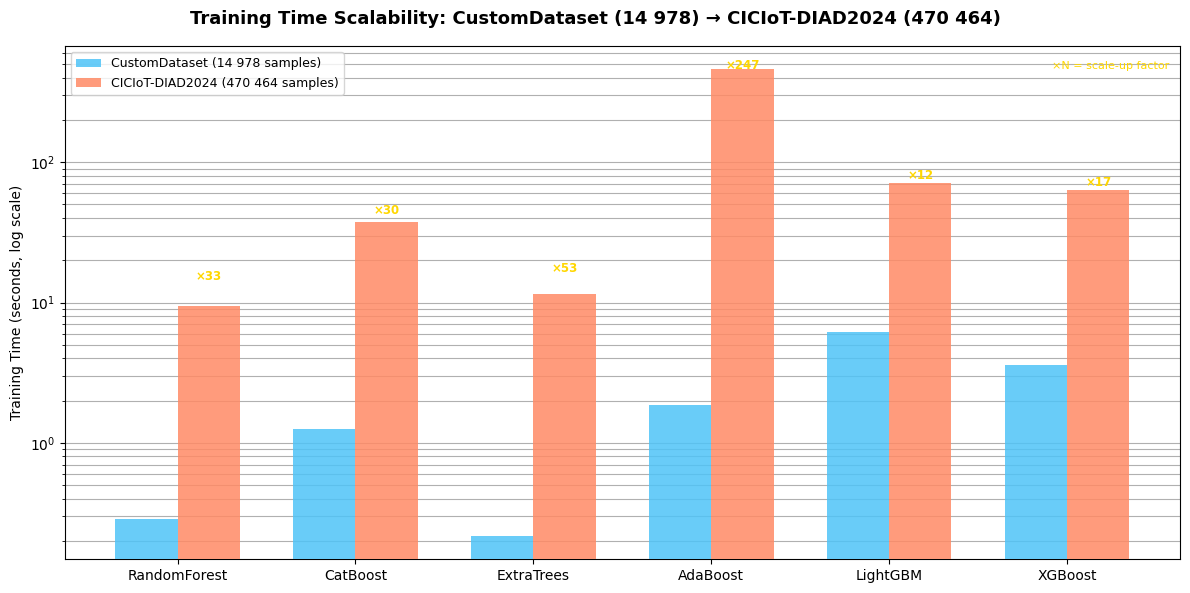

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Training Time Scalability: CustomDataset (14 978) → CICIoT-DIAD2024 (470 464)',
             fontsize=13, fontweight='bold')

x = np.arange(len(MODELS))
w = 0.35

v_cds = [cds.loc[m, 'Train_Time'] for m in MODELS]
v_cic = [cic.loc[m, 'Train_Time'] for m in MODELS]

b1 = ax.bar(x - w/2, v_cds, w, label='CustomDataset (14 978 samples)',
            color='#4fc3f7', alpha=0.85, zorder=3)
b2 = ax.bar(x + w/2, v_cic, w, label='CICIoT-DIAD2024 (470 464 samples)',
            color='#ff8a65', alpha=0.85, zorder=3)

# Scale-up ratio annotation
for i, model in enumerate(MODELS):
    ratio = v_cic[i] / v_cds[i]
    ax.text(x[i] + w/2, v_cic[i] + 5, f'×{ratio:.0f}',
            ha='center', fontsize=8.5, color='#ffd700', fontweight='bold')

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(MODELS, fontsize=10)
ax.set_ylabel('Training Time (seconds, log scale)', fontsize=10)
ax.legend(fontsize=9)
ax.yaxis.grid(True, zorder=0, which='both')
ax.set_axisbelow(True)
ax.text(0.99, 0.97, '×N = scale-up factor', transform=ax.transAxes,
        ha='right', va='top', fontsize=8, color='#ffd700')

plt.tight_layout()
plt.savefig('fig8_scalability.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()